In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import BorderlineSMOTE

In [2]:
# Đọc dữ liệu thực tế đã được xử lý
# Bạn có thể thay đổi đường dẫn tới file dataset cleaned khác nếu muốn
file_path = "Experiment/Test_ecoli4_25032026_095222/Test_ecoli4_dataset_cleaned.csv"
df = pd.read_csv(file_path)

# Tách đặc trưng (X) và nhãn (y)
X = df.drop(columns=['label']).values
y = df['label'].values

# Chuyển đổi nhãn về định dạng 0 (đa số) và 1 (thiểu số)
# Thường nhãn trong tập xử lý là -1 (đa số) và 1 (thiểu số)
if -1 in y or -1.0 in y:
    y = np.where(y == -1, 0, 1)

# Dùng PCA để giảm chiều dữ liệu gốc xuống 2D (phục vụ việc trực quan hóa trên tọa độ 2 trục)
pca = PCA(n_components=2)
X = pca.fit_transform(X)

print(f"Tổng số mẫu: {len(y)}")
print(f"Số mẫu lớp đa số (0): {sum(y==0)}")
print(f"Số mẫu lớp thiểu số (1): {sum(y==1)}")

Tổng số mẫu: 336
Số mẫu lớp đa số (0): 316
Số mẫu lớp thiểu số (1): 20


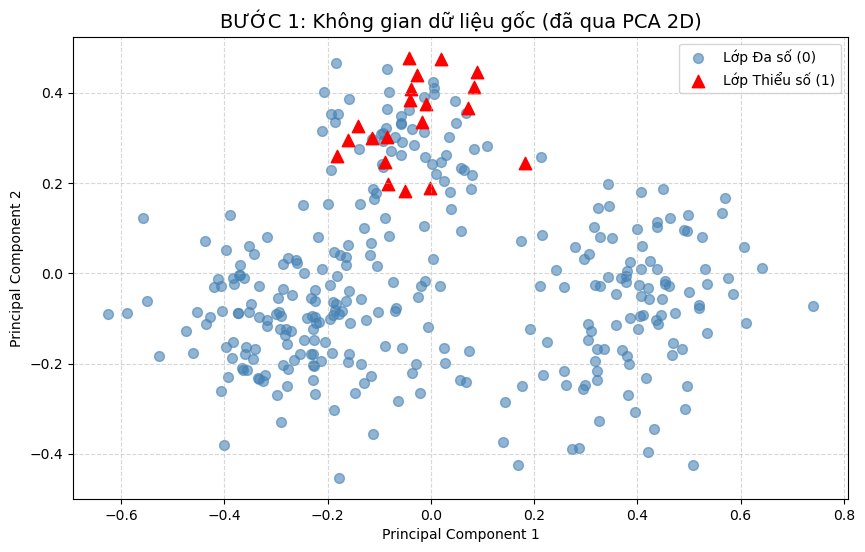

In [3]:
# Cell 3: BƯỚC 1 - Trực quan hóa Dữ liệu gốc (2D PCA)
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Lớp Đa số (0)', color='steelblue', alpha=0.6, s=50)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Lớp Thiểu số (1)', color='red', marker='^', s=80)
plt.title("BƯỚC 1: Không gian dữ liệu gốc (đã qua PCA 2D)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

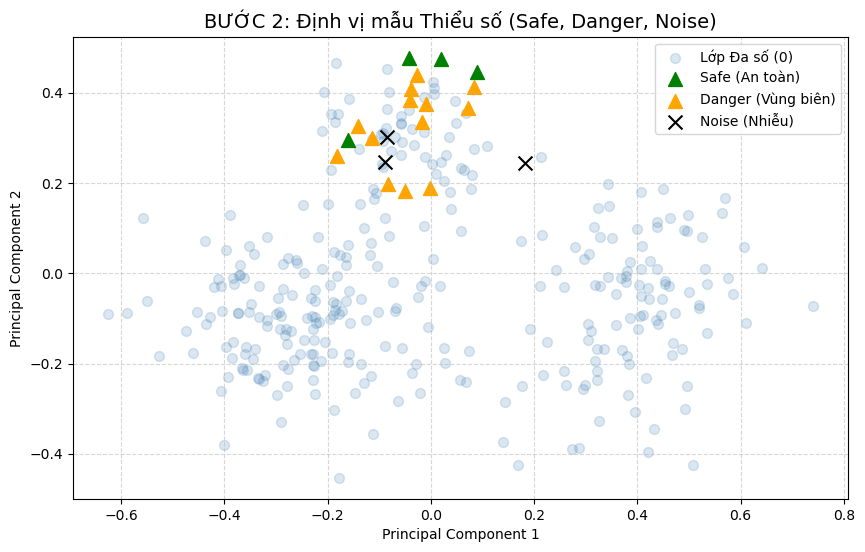

In [4]:
# Cell 4: BƯỚC 2 - BL-SMOTE định vị vùng ranh giới (Safe, Danger, Noise)
# Cài đặt K=5 láng giềng theo đúng lý thuyết thuật toán
K = 5
nn = NearestNeighbors(n_neighbors=K + 1)  # +1 vì bao gồm cả chính nó
nn.fit(X)

minority_indices = np.where(y == 1)[0]
safe, danger, noise = [], [], []

for idx in minority_indices:
    # Tìm K láng giềng của mẫu thiểu số (loại bỏ chính nó)
    neighbors = nn.kneighbors(X[idx].reshape(1, -1), return_distance=False)[0][1:]
    # Đếm số láng giềng thuộc lớp đa số (m)
    majority_count = np.sum(y[neighbors] == 0)

    # Phân loại dựa trên Borderline-SMOTE
    if majority_count == K:
        noise.append(idx)
    elif majority_count >= K / 2:
        danger.append(idx)
    else:
        safe.append(idx)

plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Lớp Đa số (0)', color='steelblue', alpha=0.2, s=50)
if safe:
    plt.scatter(X[safe][:, 0], X[safe][:, 1], label='Safe (An toàn)', color='green', marker='^', s=100)
if danger:
    plt.scatter(X[danger][:, 0], X[danger][:, 1], label='Danger (Vùng biên)', color='orange', marker='^', s=100)
if noise:
    plt.scatter(X[noise][:, 0], X[noise][:, 1], label='Noise (Nhiễu)', color='black', marker='x', s=100)

plt.title("BƯỚC 2: Định vị mẫu Thiểu số (Safe, Danger, Noise)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

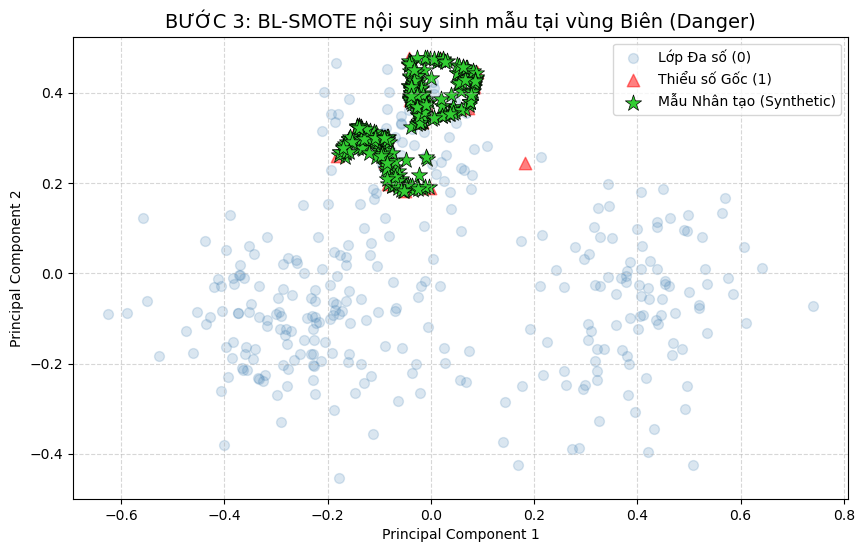

In [5]:
# Cell 5: BƯỚC 3 - Bơm mẫu tổng hợp vào vùng Danger
# Sử dụng thư viện imblearn để sinh mẫu
bl_smote = BorderlineSMOTE(random_state=42, kind='borderline-1', k_neighbors=K)
X_res, y_res = bl_smote.fit_resample(X, y)

# Tách riêng các mẫu nhân tạo (Synthetic) vừa được sinh ra
num_original = len(X)
X_synthetic = X_res[num_original:]

plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Lớp Đa số (0)', color='steelblue', alpha=0.2, s=50)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Thiểu số Gốc (1)', color='red', marker='^', s=80, alpha=0.5)
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], label='Mẫu Nhân tạo (Synthetic)', color='limegreen', marker='*', s=150, edgecolor='black', linewidth=0.5)

plt.title("BƯỚC 3: BL-SMOTE nội suy sinh mẫu tại vùng Biên (Danger)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

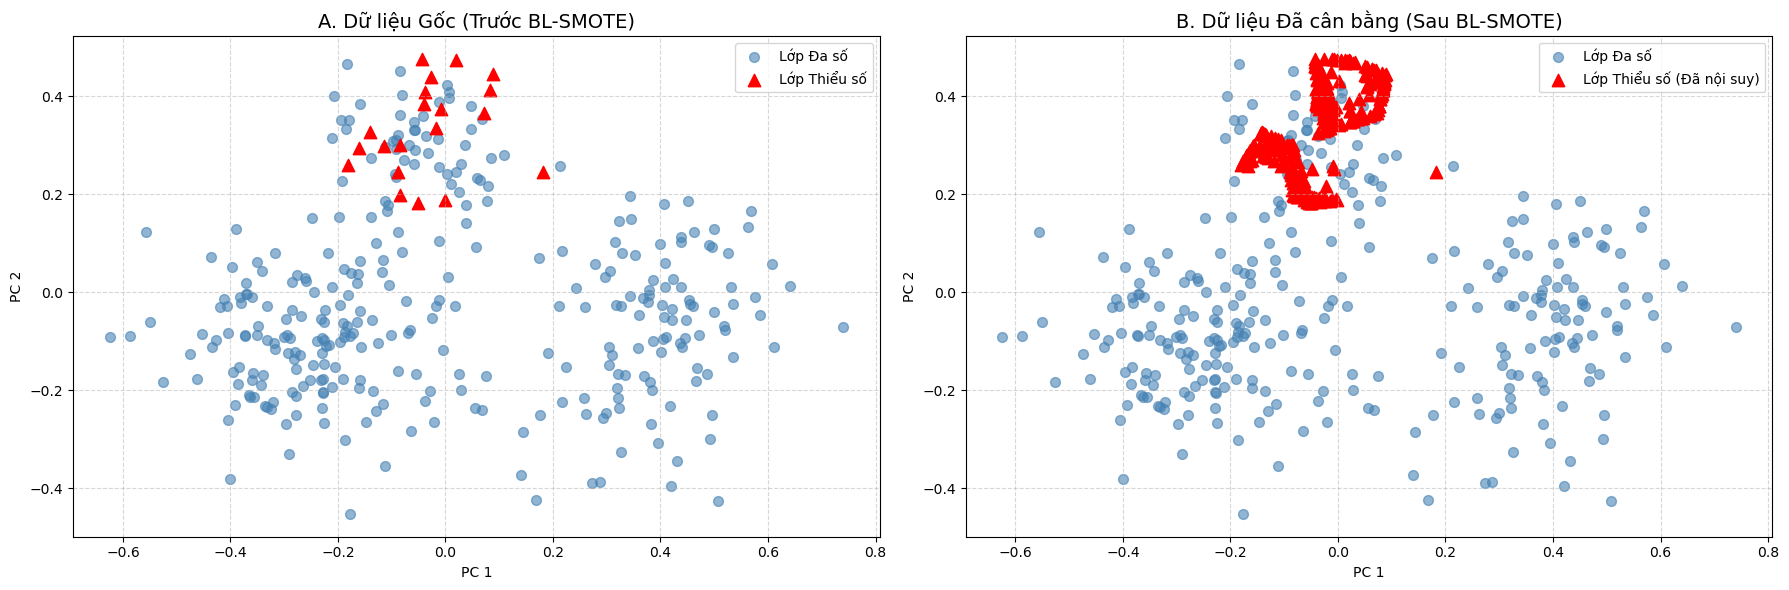

In [6]:
# Cell 6: BƯỚC 4 - So sánh Trước và Sau
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ trước khi cân bằng
axes[0].scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Lớp Đa số', color='steelblue', alpha=0.6, s=50)
axes[0].scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Lớp Thiểu số', color='red', marker='^', s=80)
axes[0].set_title("A. Dữ liệu Gốc (Trước BL-SMOTE)", fontsize=14)
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Biểu đồ sau khi cân bằng
axes[1].scatter(X_res[y_res == 0][:, 0], X_res[y_res == 0][:, 1], label='Lớp Đa số', color='steelblue', alpha=0.6, s=50)
axes[1].scatter(X_res[y_res == 1][:, 0], X_res[y_res == 1][:, 1], label='Lớp Thiểu số (Đã nội suy)', color='red', marker='^', s=80)
axes[1].set_title("B. Dữ liệu Đã cân bằng (Sau BL-SMOTE)", fontsize=14)
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()